# Preview Sentinel-2 test chips
Run the code cell to emit PNG previews for a subset of tiles.

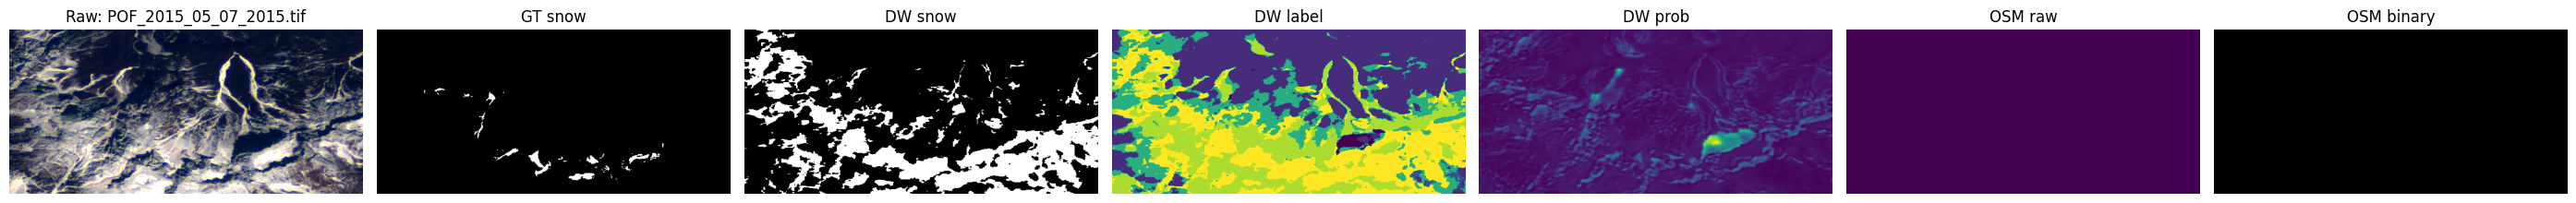

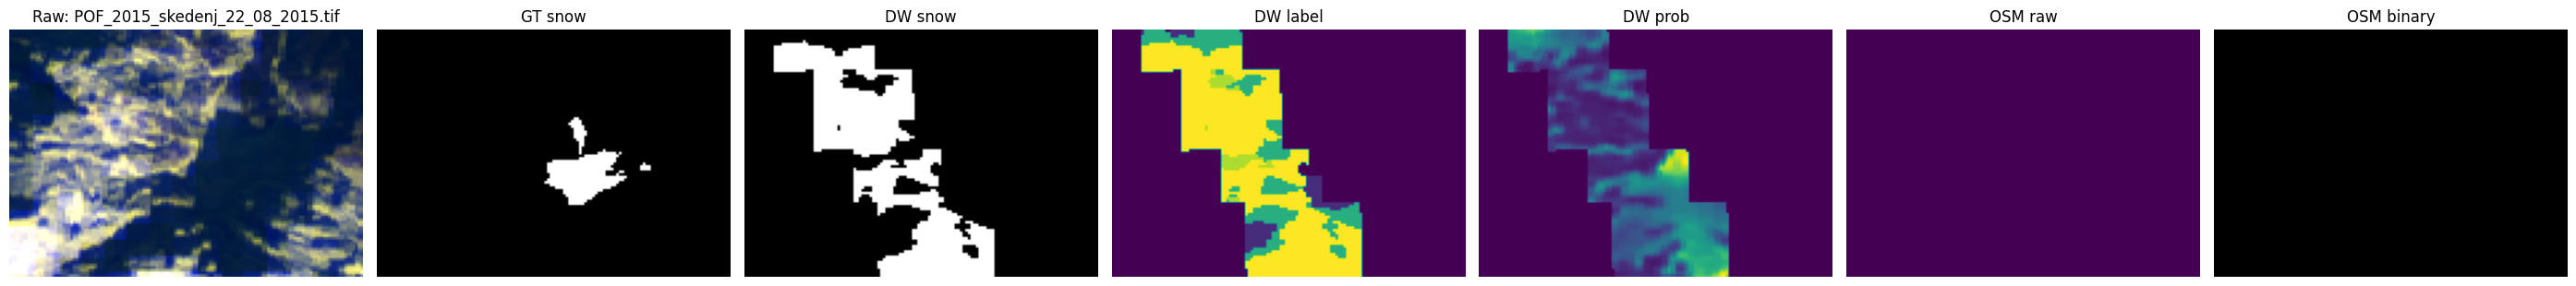

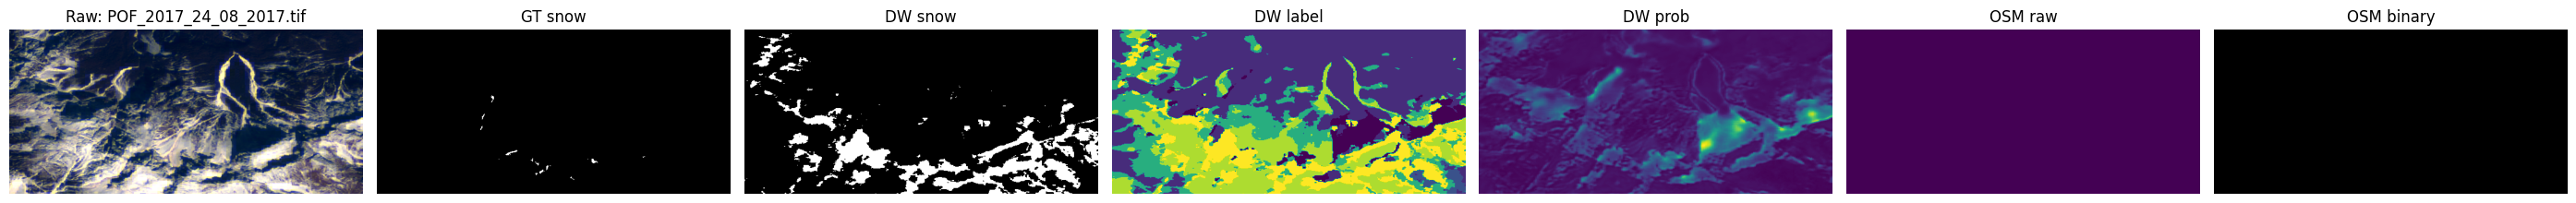

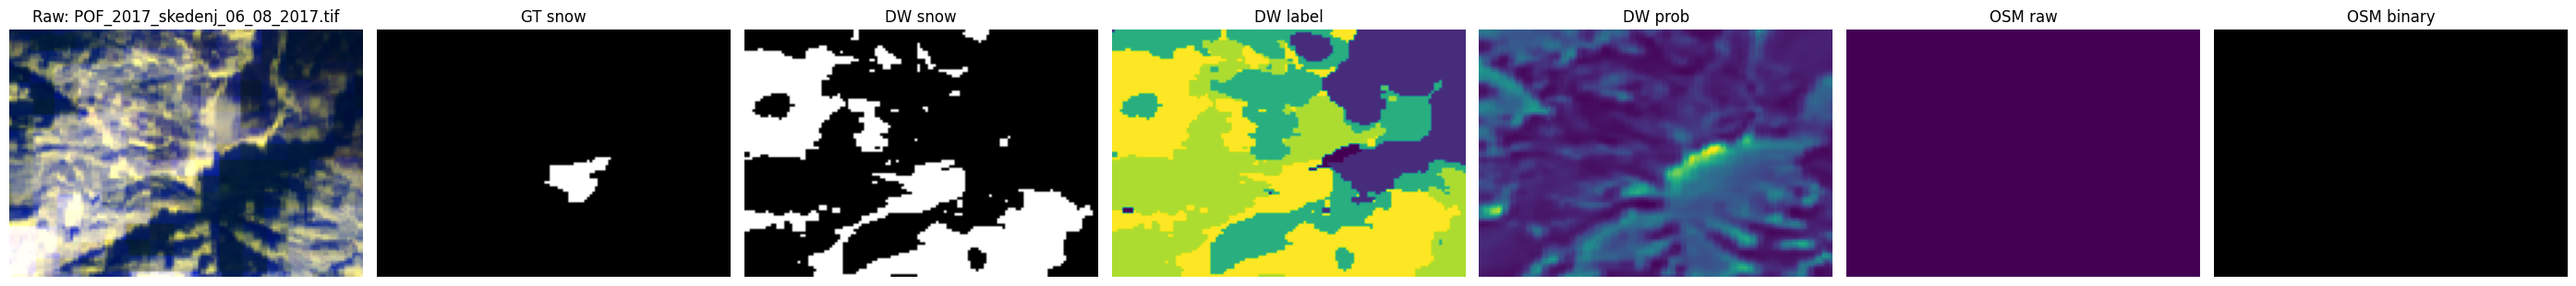

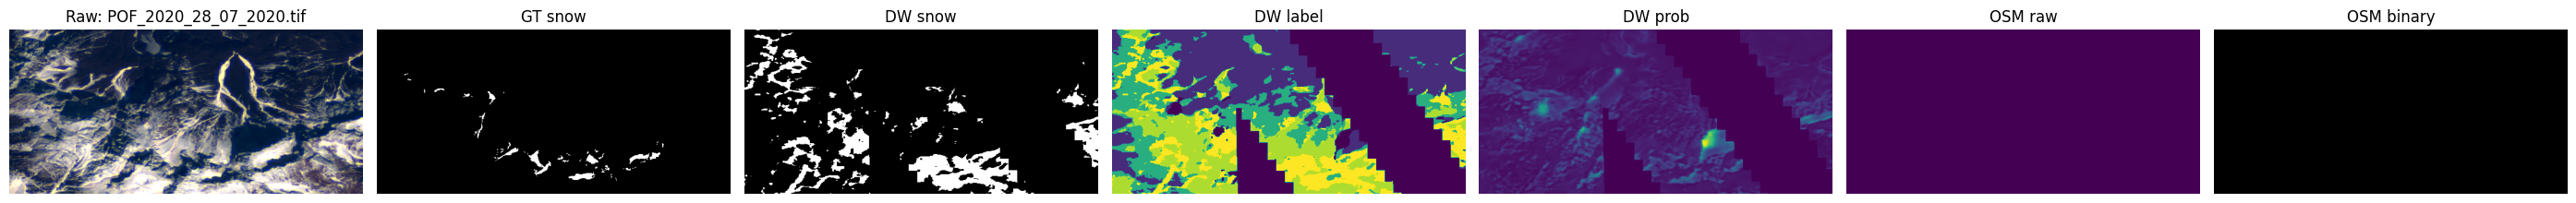

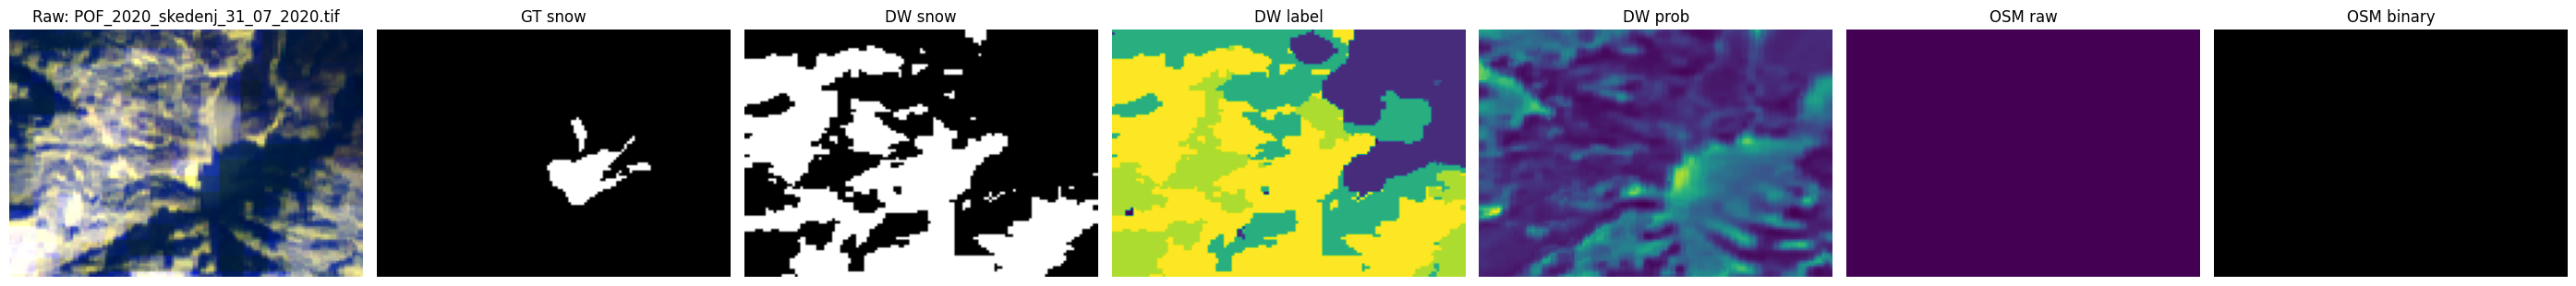

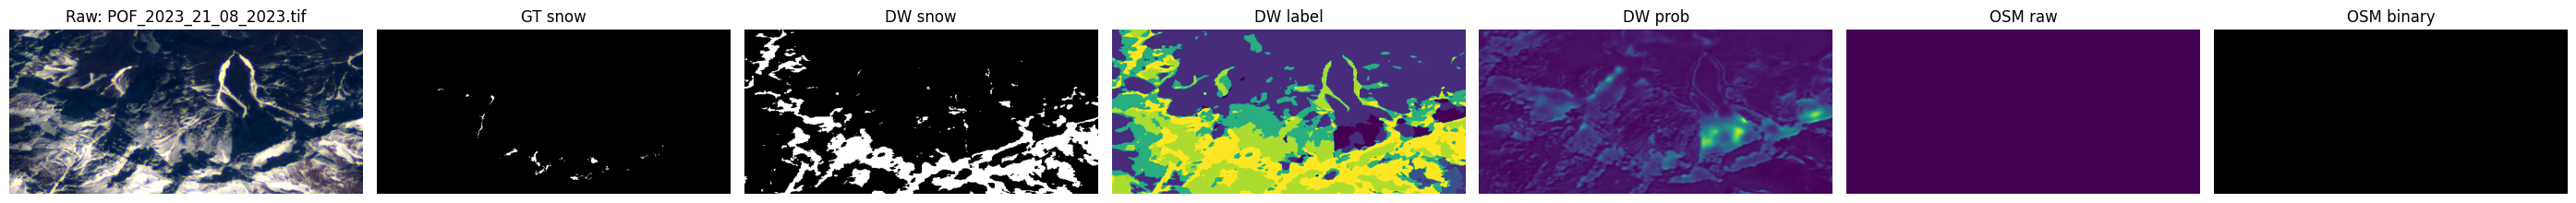

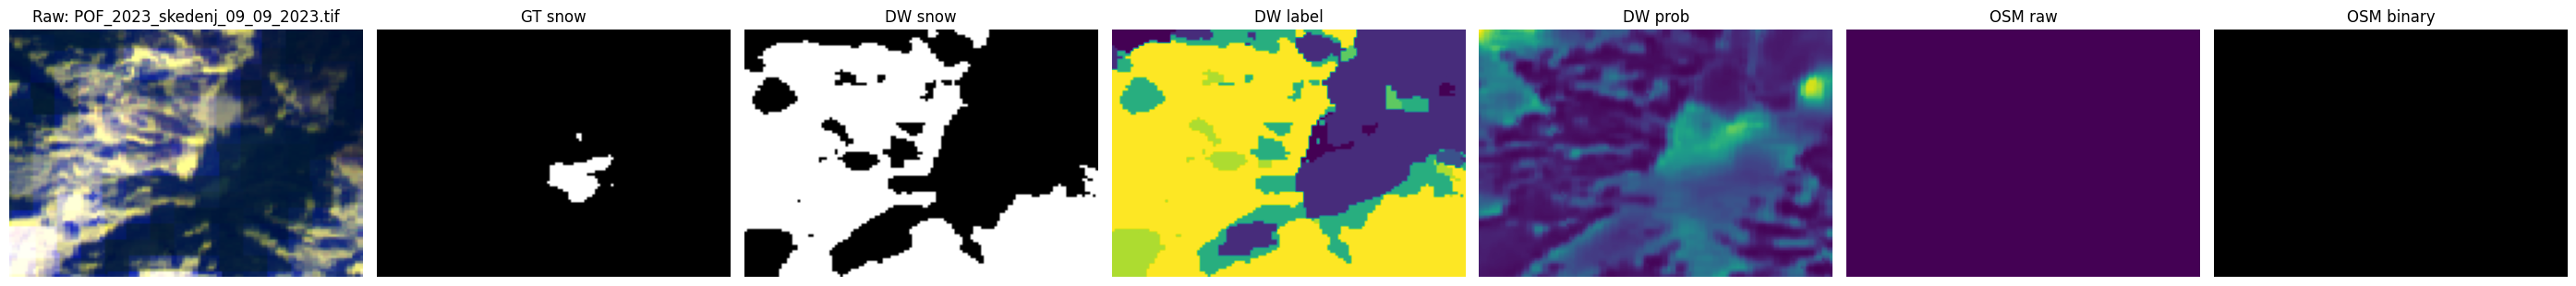

In [2]:
#!/usr/bin/env python3
"""Preview Sentinel-2 chips with all available labels from the test dataset."""
from __future__ import annotations

import argparse
import logging
from pathlib import Path
try:
    NOTEBOOK_ROOT = Path(__file__).resolve().parent
except NameError:
    NOTEBOOK_ROOT = Path.cwd()
from typing import Iterable, List, Optional

import matplotlib.pyplot as plt
import numpy as np
import rasterio

LOGGER = logging.getLogger("preview_test_dataset")
RGB_BANDS = (3, 2, 1)
TEST_DATASET_ROOT_CANDIDATES = [
    NOTEBOOK_ROOT / "test_dataset",
    NOTEBOOK_ROOT.parent / "2_download_test_data_and_create_test_dataset" / "test_dataset",
    Path("2_download_test_data_and_create_test_dataset/test_dataset"),
    Path("../2_download_test_data_and_create_test_dataset/test_dataset"),
    Path("../../2_download_test_data_and_create_test_dataset/test_dataset"),
]

def find_test_dataset_root() -> Path:
    for candidate in TEST_DATASET_ROOT_CANDIDATES:
        if candidate.exists():
            return candidate.resolve()
    raise FileNotFoundError("Could not locate test_dataset directory.")


NOTEBOOK_ARGS: List[str] = []  # set e.g. ["--limit", "10"] before running in notebook mode


def choose_samples(raw_dir: Path, limit: int) -> List[Path]:
    candidates = sorted(raw_dir.glob("*.tif"))
    return candidates if limit <= 0 else candidates[:limit]


def load_rgb(path: Path) -> np.ndarray:
    with rasterio.open(path) as dataset:
        bands = [b for b in RGB_BANDS if b <= dataset.count]
        if not bands:
            raise ValueError(f"{path.name} lacks RGB bands")
        rgb = dataset.read(bands)
    rgb = np.clip(rgb.astype(np.float32), a_min=0, a_max=None)
    rgb_min = np.percentile(rgb, 2)
    rgb_max = np.percentile(rgb, 98)
    scaled = np.clip((rgb - rgb_min) / max(rgb_max - rgb_min, 1e-6), 0.0, 1.0)
    return scaled.transpose(1, 2, 0)


def load_label(path: Path) -> np.ndarray:
    with rasterio.open(path) as dataset:
        label = dataset.read(1)
    return label


def plot_previews(
    tile_path: Path,
    gt_label_path: Path,
    snow_label_path: Path,
    dw_label_path: Path,
    dw_prob_path: Path,
    osm_raw_path: Path,
    osm_bin_path: Path,
) -> None:
    rgb = load_rgb(tile_path)
    gt_label = load_label(gt_label_path) if gt_label_path.exists() else None
    snow_label = load_label(snow_label_path) if snow_label_path.exists() else None
    dw_label = load_label(dw_label_path) if dw_label_path.exists() else None
    dw_prob = load_label(dw_prob_path) if dw_prob_path.exists() else None
    osm_raw = load_label(osm_raw_path) if osm_raw_path.exists() else None
    osm_bin = load_label(osm_bin_path) if osm_bin_path.exists() else None

    # ----------- SAVE PREVIEWS (same logic as first function) -----------
    previews_dir = tile_path.parent.parent / "previews"
    previews_dir.mkdir(parents=True, exist_ok=True)

    base_name = tile_path.stem

    # save raw RGB
    plt.imsave(previews_dir / f"{base_name}_raw.png", rgb)

    # save snow (DW snow)
    if snow_label is not None:
        plt.imsave(
            previews_dir / f"{base_name}_snow.png",
            snow_label,
            cmap="gray",
            vmin=0,
            vmax=1,
        )
    # --------------------------------------------------------------------

    
    fig, axes = plt.subplots(1, 7, figsize=(28, 5))
    axes[0].imshow(rgb)
    axes[0].set_title(f"Raw: {tile_path.name}")
    axes[0].axis("off")
    axes[1].imshow(gt_label if gt_label is not None else np.zeros(rgb.shape[:2]), cmap="gray", vmin=0, vmax=1)
    axes[1].set_title("GT snow")
    axes[1].axis("off")
    axes[2].imshow(snow_label if snow_label is not None else np.zeros(rgb.shape[:2]), cmap="gray", vmin=0, vmax=1)
    axes[2].set_title("DW snow")
    axes[2].axis("off")
    axes[3].imshow(dw_label if dw_label is not None else np.zeros(rgb.shape[:2]), cmap="viridis")
    axes[3].set_title("DW label")
    axes[3].axis("off")
    axes[4].imshow(dw_prob if dw_prob is not None else np.zeros(rgb.shape[:2]), cmap="viridis")
    axes[4].set_title("DW prob")
    axes[4].axis("off")
    axes[5].imshow(osm_raw if osm_raw is not None else np.zeros(rgb.shape[:2]), cmap="viridis")
    axes[5].set_title("OSM raw")
    axes[5].axis("off")
    axes[6].imshow(osm_bin if osm_bin is not None else np.zeros(rgb.shape[:2]), cmap="gray", vmin=0, vmax=1)
    axes[6].set_title("OSM binary")
    axes[6].axis("off")
    plt.tight_layout()


def parse_args(argv: Optional[List[str]] = None) -> argparse.Namespace:
    parser = argparse.ArgumentParser(description=__doc__)
    parser.add_argument(
        "--raw-dir",
        type=Path,
        default=NOTEBOOK_ROOT / "test_dataset" / "raw",
        help="Directory containing Sentinel-2 TIFFs",
    )
    parser.add_argument(
        "--gt-label-dir",
        type=Path,
        default=NOTEBOOK_ROOT / "test_dataset" / "given_gt_snow_labels",
        help="Directory containing GT snow labels",
    )
    parser.add_argument(
        "--snow-label-dir",
        type=Path,
        default=NOTEBOOK_ROOT / "test_dataset" / "snow_labels",
        help="Directory containing derived snow labels",
    )
    parser.add_argument(
        "--dw-label-dir",
        type=Path,
        default=NOTEBOOK_ROOT / "test_dataset" / "all_labels",
        help="Directory containing Dynamic World labels",
    )
    parser.add_argument(
        "--dw-prob-dir",
        type=Path,
        default=NOTEBOOK_ROOT / "test_dataset" / "all_labels_probabilities",
        help="Directory containing Dynamic World probabilities",
    )
    parser.add_argument(
        "--osm-raw-dir",
        type=Path,
        default=NOTEBOOK_ROOT / "test_dataset" / "osm_raw",
        help="Directory containing raw OSM rasters",
    )
    parser.add_argument(
        "--osm-bin-dir",
        type=Path,
        default=NOTEBOOK_ROOT / "test_dataset" / "osm_binary",
        help="Directory containing binary OSM rasters",
    )
    parser.add_argument(
        "--limit",
        type=int,
        default=0,
        help="Number of tiles to preview (0 = all)",
    )
    parser.add_argument(
        "--log-level",
        default="INFO",
        choices=("DEBUG", "INFO", "WARNING", "ERROR"),
    )
    return parser.parse_args(argv)


def main() -> None:
    args = parse_args(NOTEBOOK_ARGS or None)
    logging.basicConfig(level=getattr(logging, args.log_level))
    samples = choose_samples(args.raw_dir, args.limit)
    if not samples:
        LOGGER.warning("No tiles found in %s", args.raw_dir)
        return
    for sample in samples:
        gt_label_path = args.gt_label_dir / sample.name
        snow_label_path = args.snow_label_dir / sample.name
        dw_label_path = args.dw_label_dir / sample.name
        dw_prob_path = args.dw_prob_dir / sample.name
        osm_raw_path = args.osm_raw_dir / sample.name
        osm_bin_path = args.osm_bin_dir / sample.name
        try:
            plot_previews(
                sample,
                gt_label_path,
                snow_label_path,
                dw_label_path,
                dw_prob_path,
                osm_raw_path,
                osm_bin_path,
            )
        except Exception as exc:
            LOGGER.error("Failed to preview %s: %s", sample.name, exc)


if __name__ == "__main__":
    import sys
    if any(arg.startswith("-f") for arg in sys.argv[1:]):
        sys.argv = [sys.argv[0]]
    main()
